In [2]:
%load_ext autoreload
%autoreload 2

# Multi-Station QC Evaluation

This notebook loads hourly observations for three stations, converts them to daily values, and runs the modular QC flow for each station. The station selection uses the shared SQL query for network 2 and the requested variables.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import sqlalchemy as sa
from sqlalchemy.orm import Session
# Make the function folder and package root available
sys.path.append(os.path.abspath('./func/'))
sys.path.append(os.path.abspath('../../'))


save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)
session

In [3]:
from func_run_qc_pipeline import *

from visualizaion_func import (
    plot_weather_data,
    plot_timeseries_with_naught_missing_multi,
    plot_multi_range_check,
    plot_clim_check_multi,
    plot_inttemp_tas_timeseries,
    plot_inttemp_snow_tmin_timeseries,
    plot_inttemp_snow_fall_dpth_timeseries,
    plot_inttemp_snow_precip_timeseries,
)

In [4]:
sql_text = sa.text("""
SELECT s.station_id, h.station_name
FROM meta_history h
JOIN meta_station s
    ON h.station_id = s.station_id
WHERE s.network_id = 2

AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'MINIMUM_AIR_TEMPERATURE'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'MAXIMUM_AIR_TEMPERATURE'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'min_air_temp_snc_last_reset'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'max_air_temp_snc_last_reset'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'air_temp'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'pcpn_amt_pst1hr'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'snwfl_amt_pst1hr'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'snw_dpth'
)
;

""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)

df

,station_id,station_name
0,2668,Nicolum Creek
1,2794,Nordic 2
2,2955,North Courtenay
3,2902,Onion Lake
4,2764,Paulson Summit
...,...,...
97,2834,West Twin Creek
98,2870,Enterprise
99,2891,Endgoal
100,2906,Salvus


In [5]:
# replace with the three station IDs you want to evaluate
stations_to_eval = df['station_id'].iloc[7:15]
# stations_to_eval = [2813]

sql_text = sa.text(
    """
SELECT s.station_id, o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 2
AND s.station_id IN :stations
AND v.net_var_name IN (
    'MINIMUM_AIR_TEMPERATURE',
    'MAXIMUM_AIR_TEMPERATURE',
    'min_air_temp_snc_last_reset',
    'max_air_temp_snc_last_reset',
    'air_temp',
    'pcpn_amt_pst1hr',
    'snwfl_amt_pst1hr',
    'snw_dpth'
)
ORDER BY s.station_id, o.obs_time
""")

with engine.begin() as conn:
    df_obs = pd.read_sql(sql_text, conn, params={
                         "stations": tuple(stations_to_eval)})

print("Loaded observations for", df_obs["station_id"].nunique(), "stations")
print(df_obs.head())

Loaded observations for 8 stations
   station_id            obs_time             net_var_name  datum
0        2657 1997-09-16 16:00:00  MAXIMUM_AIR_TEMPERATURE    4.7
1        2657 1997-09-16 16:00:00  MINIMUM_AIR_TEMPERATURE    3.3
2        2657 1997-09-16 17:00:00  MINIMUM_AIR_TEMPERATURE    3.3
3        2657 1997-09-16 17:00:00  MAXIMUM_AIR_TEMPERATURE    4.7
4        2657 1997-09-16 18:00:00  MINIMUM_AIR_TEMPERATURE    3.3


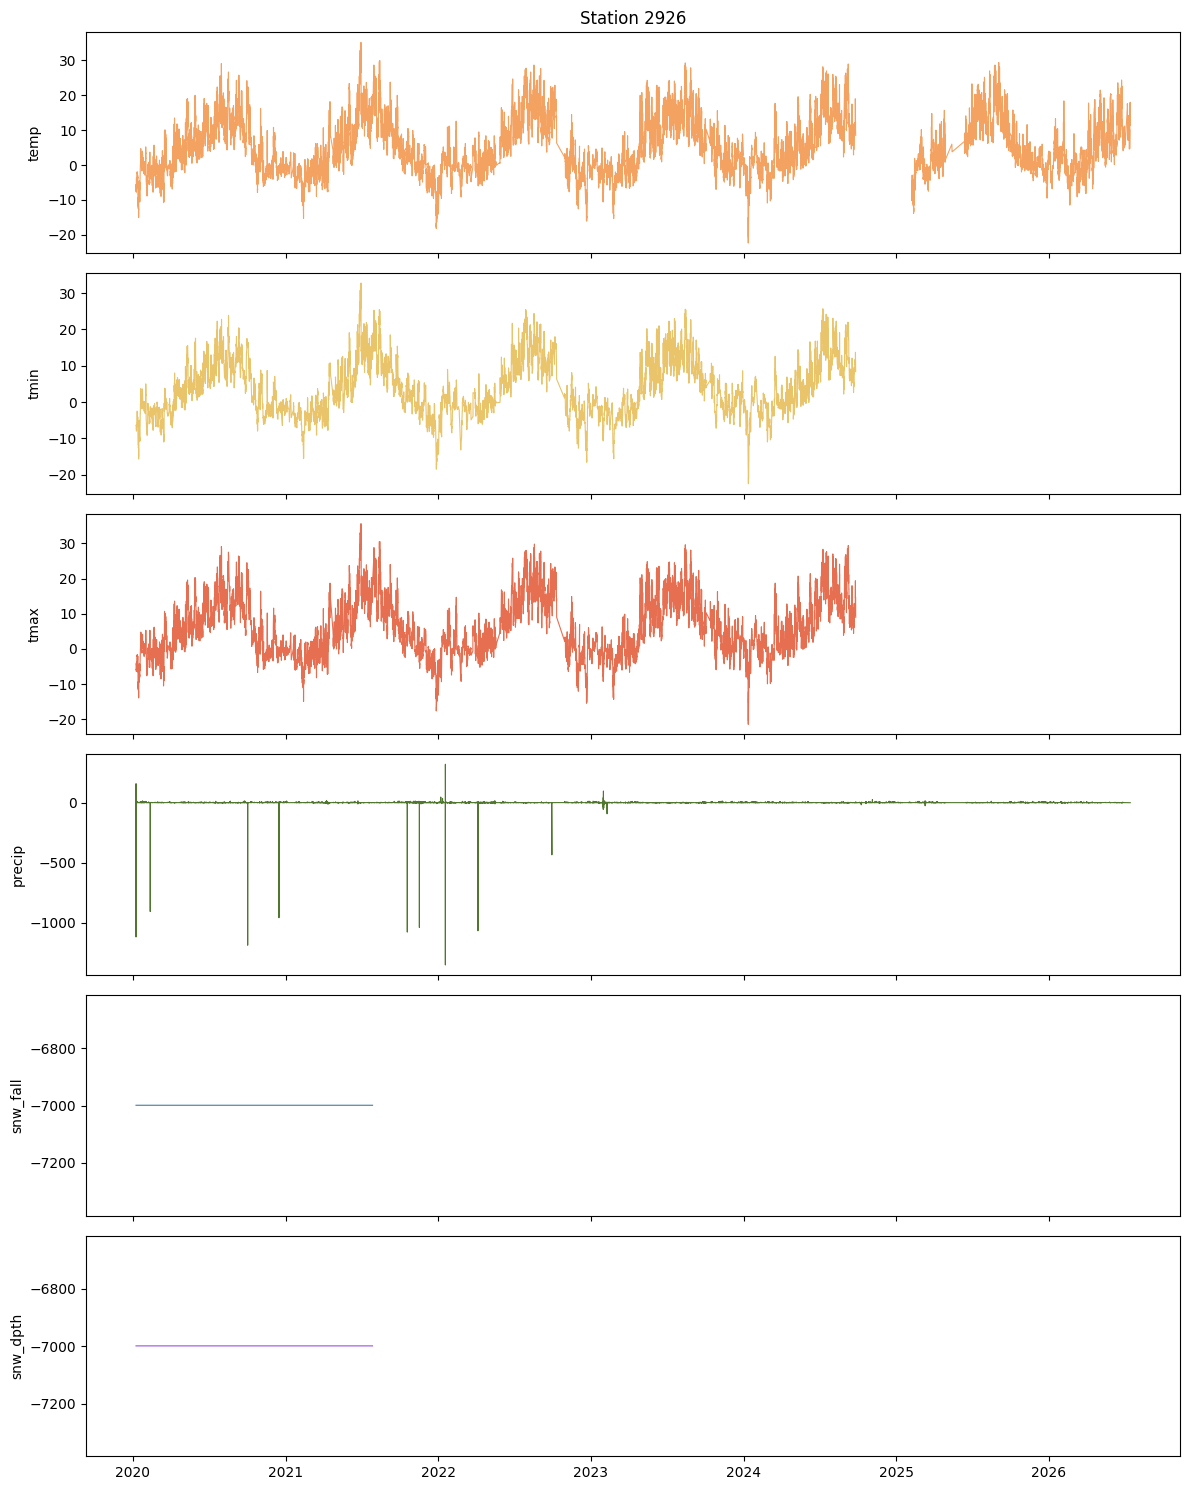

In [6]:
df_sql_list = []

for station_id, df_station in df_obs.groupby("station_id"):

    df_station = df_station.copy()
    df_station["obs_time"] = pd.to_datetime(df_station["obs_time"])

    df_sql = df_station.pivot_table(
        index="obs_time",
        columns="net_var_name",
        values="datum"
    ).sort_index()

    df_sql = df_sql.rename(columns={
        "min_air_temp_snc_last_reset": "tmin",
        "max_air_temp_snc_last_reset": "tmax",
        "air_temp": "temp",
        "pcpn_amt_pst1hr": "precip",
        "snwfl_amt_pst1hr": "snw_fall"
    })

    df_sql_list.append((station_id, df_sql))

stat_id = 0
station_df = df_sql_list[stat_id][1]

station_df = station_df[[
    'temp',
    'tmin',
    'tmax',
    'precip',
    'snw_fall',
    'snw_dpth'
]]

start_time = station_df.apply(lambda col: col.first_valid_index()).min()

station_df_trim = station_df.loc[start_time:]

color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
    "precip": "#4f772d",
}

plot_weather_data(station_df_trim, color_map=color_map,
                  title=f"Station {station_id}")

## Build daily data and run QC for each station

The following cells convert hourly data to daily, then execute the modular QC pipeline for each station.

In [130]:
# Initialize lists to collect results across all stations
all_cleaned_with_flags = []
all_flag_summaries = []
all_station_summaries = []

# Track problematic stations
problem_station_ids = []

# Re-run the analysis to collect summary tables
for station_id, df_station in df_obs.groupby("station_id"):

    print(station_id)

    daily_all = build_daily_all(df_station)
    result = run_qc_result_pipeline(daily_all, value_cols)

    # Generate cleaned dataset with all flags
    cleaned_with_flags = create_cleaned_dataset_with_flags(
        station_id,
        result["daily_cleaned"],
        result["naught_all"],
        result["range_results"],
        result["dup_result_dict"],
        result["ind_result_dict"],
        result["gap_result_dict"],
        result["clim_flag_df"],
        result["inttemp_tas_result"],
        result["inttemp_snow_tmin_result"],
        result["inttemp_snow_fall_dpth_result"],
        result["inttemp_snow_precip_result"],
        value_cols
    )

    all_cleaned_with_flags.append(cleaned_with_flags)

    # Generate flag summary
    flag_summary = create_flag_summary(
        cleaned_with_flags,
        station_id,
        value_cols,
        miss_result_dict=result["miss_result_dict"]
    )

    all_flag_summaries.append(flag_summary)

    flag_summary_var = summarize_variable_flag_rate(flag_summary)

    # --------------------------------------------------
    # Station evaluation
    # --------------------------------------------------
    daily_cleaned = result["daily_cleaned"]

    completeness_by_year = analyze_temporal_coverage(
        daily_cleaned,
        value_cols,
        miss_result_dict=result["miss_result_dict"]
    )

    variable_quality = evaluate_station_quality(
        daily_cleaned,
        value_cols,
        miss_result_dict=result["miss_result_dict"],
        summary_flags=flag_summary_var
    )

    # Overall station rating
    station_rating, recommendation = get_station_rating(
        [q["rating"] for q in variable_quality.values()]
    )

    print(station_rating)
    print(recommendation)

    # Record problematic stations
    if station_rating != "✅ GOOD QUALITY":
        problem_station_ids.append(station_id)

    # --------------------------------------------------
    # Generate station evaluation summary
    # --------------------------------------------------
    station_summary = create_station_evaluation_summary(
        daily_cleaned,
        station_id,
        completeness_by_year,
        variable_quality,
        station_rating,
        recommendation,
        value_cols
    )

    all_station_summaries.append(station_summary)

# Combine all results into flat tables
cleaned_data_master = pd.concat(all_cleaned_with_flags, ignore_index=True)
flag_summary_master = pd.concat(all_flag_summaries, ignore_index=True)
station_summary_master = pd.concat(all_station_summaries, ignore_index=True)

2657
STATION QUALITY EVALUATION SUMMARY (QC SCORING ENGINE)

VARIABLE-BY-VARIABLE QUALITY ASSESSMENT
--------------------------------------------------------------------------------

⚠️⚠️ TEMP         PROBLEMATIC 
   Missing rate:  38.54%
   Flag rate:      0.00%
   Large gaps:   NO
   ⚠️ Missing rate 38.5%

⚠️⚠️ TMIN         PROBLEMATIC 
   Missing rate:  38.54%
   Flag rate:      0.00%
   Large gaps:   NO
   ⚠️ Missing rate 38.5%

⚠️⚠️ TMAX         PROBLEMATIC 
   Missing rate:  38.54%
   Flag rate:      0.00%
   Large gaps:   NO
   ⚠️ Missing rate 38.5%

✅ PRECIP       GOOD        
   Missing rate:  19.81%
   Flag rate:      0.00%
   Large gaps:   NO

❌❌ SNW_FALL     UNUSABLE    
   Missing rate:    nan%
   Flag rate:      0.00%
   Large gaps:   NO
   ⚠️ Missing rate unavailable (all values missing?)

❌❌ SNW_DPTH     UNUSABLE    
   Missing rate:    nan%
   Flag rate:      0.00%
   Large gaps:   NO
   ⚠️ Missing rate unavailable (all values missing?)

SUMMARY:
  ✅ GOOD        : 1
  

In [131]:
problem_station_ids

[2657, 2813, 2926]

## Export Summary Tables to CSV

Save the generated summary tables to CSV files for external analysis and reporting.

In [133]:
import os
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path(
    '/workspaces/crmprtd/Quanlity_Control/single_station/evaluation_table')
output_dir.mkdir(parents=True, exist_ok=True)

# Save the three summary tables to CSV
cleaned_data_file = output_dir / 'cleaned_data_with_flags.csv'
flag_summary_file = output_dir / 'flag_summary.csv'
station_summary_file = output_dir / 'station_evaluation_summary.csv'

cleaned_data_master.to_csv(cleaned_data_file, index=False)
flag_summary_master.to_csv(flag_summary_file, index=False)
station_summary_master.to_csv(station_summary_file, index=False)

print(f"✅ CSV files saved successfully!\n")
print(f"1. Cleaned data with flags: {cleaned_data_file}")
print(f"   Shape: {cleaned_data_master.shape}\n")
print(f"2. Flag summary: {flag_summary_file}")
print(f"   Shape: {flag_summary_master.shape}\n")
print(f"3. Station evaluation summary: {station_summary_file}")
print(f"   Shape: {station_summary_master.shape}")

✅ CSV files saved successfully!

1. Cleaned data with flags: /workspaces/crmprtd/Quanlity_Control/single_station/evaluation_table/cleaned_data_with_flags.csv
   Shape: (18496, 69)

2. Flag summary: /workspaces/crmprtd/Quanlity_Control/single_station/evaluation_table/flag_summary.csv
   Shape: (544, 5)

3. Station evaluation summary: /workspaces/crmprtd/Quanlity_Control/single_station/evaluation_table/station_evaluation_summary.csv
   Shape: (56, 10)
